In [ ]:
from pathlib import Path
import sys

# --- Resolve repo root (works whether you run from repo root or within notebooks/) ---
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    if (REPO_ROOT.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent
    elif (REPO_ROOT.parent.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

from IPython.display import display
from notebooks.set_up import (
    ensure_dirs,
    SYNTH_DIR,
    TABLE_DIR, FIG_DIR,
    CATE_DIR, 
)

ensure_dirs()

# Inputs
base_path = str(SYNTH_DIR) + "/"
# Outputs
output_result = str(CATE_DIR) + "/"
output_figure = str(FIG_DIR) + "/"

Estimators and evaluation utilities live in `src/causalmix/cate/`.

In [ ]:
# CATE estimators + evaluation
from causalmix.cate import *


# Application 1. Formal run of the estimator comparison with synthetic mcrpc datasets

In [0]:
# Update: Feb 23 2026
# Added CAET mean absolute bias and CI width metrics

In [0]:
# 50 repetitions for each estimator
# require two functions: summarize_results and evaluate_estimator_rep, in addition to the estimator functions and preprocess_data
## two scenarios:
## 1) causal scenario 2 without unmeasured confounding bias 2) with unmeasured confounding bias 
import numpy as np
import pandas as pd
import time
from pyspark.sql import functions as F

# -----------------------
# User paths / settings
# -----------------------
n_reps = 50
target_concurrency = 32

OUTCOME = "hosp_ed_any"
TREATMENT = "exp"

# -----------------------
# Estimator configs (NO lambdas)
# -----------------------
ESTIMATOR_CONFIGS = [
    ("XLearner-GBR",   "dummy",  "xlearner", {"method": "GBR",   "n_bootstrap": 100}),
    ("XLearner-Linear","dummy",  "xlearner", {"method": "linear","n_bootstrap": 100}),  # this is actually lasso
    ("GbrDML",         "dummy",  "dml",      {"method": "GBR", "method_cate": "GBR",   "n_bootstrap": 100}),
    ("LassoDML",       "dummy",  "dml",      {"method": "GBR", "method_cate": "lasso", "n_bootstrap": 100}),
    ("LinearDML",      "dummy",  "dml",      {"method": "GBR", "method_cate": "linear"}),
    ("GbrDR",          "dummy",  "dr",       {"method": "GBR", "method_cate": "GBR",   "n_bootstrap": 100}),
    ("LassoDR",        "dummy",  "dr",       {"method": "GBR", "method_cate": "lasso", "n_bootstrap": 100}),
    ("LinearDR",       "dummy",  "dr",       {"method": "GBR", "method_cate": "linear","n_bootstrap": 100}),
    ("CausalForest",   "onehot", "cf",       {"num_trees": 2000}),
    ("BayesianCausalForest","onehot","bcf",  {"nburn": 500, "nsim": 1000}),
]

# -----------------------
# 1) Build one Spark DF with stable idx (driver-side)
# -----------------------
data_parts = []
truth_parts = []

for rep in range(n_reps):
    # Load delta -> pandas (order preserved within pandas)
    pdf = spark.read.format("delta").load(base_path + f"df_gen_{rep}").toPandas() # change the synthetic dataset names here (biased vs. no bias): f"df_bias0_gen_{rep}"
    pdf = pdf.reset_index(drop=True)
    pdf["idx"] = np.arange(len(pdf), dtype=int)
    pdf["rep"] = rep
    data_parts.append(pdf)

    # Load truth arrays (must match pandas row order)
    true_ate = np.load("/dbfs" + base_path + f"ate_{rep}.npy") # change the synthetic truth dataset names here: f"ate_bias0_{rep}.npy"
    true_ate = float(true_ate.item() if hasattr(true_ate, "item") else true_ate) 

    true_cate = np.load("/dbfs" + base_path + f"ite_{rep}.npy") # change the synthetic truth dataset names here: f"ite_bias0_{rep}.npy"
    true_cate = np.asarray(true_cate, dtype=float)

    truth_pdf = pd.DataFrame({
        "rep": rep,
        "idx": np.arange(len(true_cate), dtype=int),
        "true_cate": true_cate,
        "true_ate": true_ate,
    })
    truth_parts.append(truth_pdf)

data_all_pdf = pd.concat(data_parts, ignore_index=True)
truth_all_pdf = pd.concat(truth_parts, ignore_index=True)
# to get the average ATE and its std across datasests
truth_ate = truth_all_pdf.agg({"true_ate": ["mean", "std"]}).reset_index()
display(truth_ate) # 0.056 (sd 0.000) for both unbiased and biased scenario

data_sdf = spark.createDataFrame(data_all_pdf)
truth_sdf = spark.createDataFrame(truth_all_pdf)

# Join so each row carries truth
joined = data_sdf.join(truth_sdf, on=["rep", "idx"], how="inner")

# -----------------------
# 2) Pandas UDF per rep (NO spark usage inside)
# -----------------------

index,true_ate
mean,0.05624335750937462
std,1.4218468167511222E-4


In [0]:
# bias = 0.02
per_rep_df

,estimator,runtime_sec,ate_hat,ate_bias,ate_stderr,ate_coverage,cate_rmse,cate_coverage,rep,n,error
0,XLearner-GBR,158.865751,0.056554,0.000291,0.092101,1,0.095941,0.831869,33,4098,
1,XLearner-Linear,117.282162,0.054305,-0.001958,0.035554,1,0.036580,0.872377,33,4098,
2,GbrDML,260.466981,0.090528,0.034265,0.130582,1,0.139161,0.859932,33,4098,
3,LassoDML,229.576758,0.090060,0.033797,0.008520,0,0.039472,0.127623,33,4098,
4,LinearDML,2.169691,0.091017,0.034754,0.009469,0,0.061784,0.858712,33,4098,
...,...,...,...,...,...,...,...,...,...,...,...
495,GbrDR,266.964224,0.076928,0.020657,0.137517,1,0.178393,0.795998,41,4098,
496,LassoDR,226.644527,0.076928,0.020657,0.006518,0,0.043555,0.213275,41,4098,
497,LinearDR,2.161226,0.076928,0.020657,0.047939,1,0.071037,0.844070,41,4098,
498,CausalForest,23.117671,0.073987,0.017717,0.009076,1,0.052831,0.782577,41,4098,


In [0]:
# bais = 0.02
summary_df

,estimator,n_reps,runtime_mean_sec,runtime_sd_sec,ate_bias_mean,ate_bias_sd,ate_coverage,cate_rmse_mean,cate_rmse_sd,cate_coverage_mean
0,BayesianCausalForest,50,260.604104,9.556541,0.020723,0.009623,0.48,0.032756,0.007296,0.854480
1,CausalForest,50,25.282901,1.796958,0.025663,0.007826,0.18,0.044337,0.005792,0.799468
2,GbrDML,50,262.752039,7.683182,0.024989,0.008763,1.00,0.140057,0.009357,0.825915
3,GbrDR,50,269.748381,7.323164,0.026775,0.009647,1.00,0.153180,0.012022,0.812904
4,LassoDML,50,224.980859,7.899721,0.023656,0.009228,0.28,0.037002,0.008962,0.261464
5,LassoDR,50,230.516547,8.434725,0.026775,0.009647,0.14,0.040726,0.008723,0.246955
6,LinearDML,50,2.143336,0.069180,0.024621,0.009221,0.24,0.060308,0.009094,0.836667
7,LinearDR,50,2.200879,0.079784,0.026775,0.009647,1.00,0.063574,0.008520,0.852421
8,XLearner-GBR,50,158.592210,4.331562,-0.001087,0.008849,1.00,0.099772,0.010590,0.828770
9,XLearner-Linear,50,116.443675,3.837057,-0.001180,0.008340,1.00,0.039996,0.007505,0.855422


In [0]:
# no bias
per_rep_df

,estimator,runtime_sec,ate_hat,ate_bias,ate_stderr,ate_coverage,cate_rmse,cate_coverage,rep,n,error
0,XLearner-GBR,157.571315,0.021657,-0.032087,0.082734,1,0.095019,0.792094,33,4098,
1,XLearner-Linear,116.505068,0.021644,-0.032099,0.035771,1,0.038967,0.789409,33,4098,
2,GbrDML,260.243689,0.037851,-0.015893,0.111817,1,0.127462,0.806979,33,4098,
3,LassoDML,224.062290,0.038394,-0.015350,0.007528,0,0.037241,0.232552,33,4098,
4,LinearDML,2.116128,0.037902,-0.015841,0.008416,1,0.051269,0.842118,33,4098,
...,...,...,...,...,...,...,...,...,...,...,...
495,GbrDR,264.701769,0.056458,0.002486,0.123144,1,0.140957,0.806735,41,4098,
496,LassoDR,225.313559,0.056458,0.002486,0.008843,1,0.021803,0.431918,41,4098,
497,LinearDR,2.151686,0.056458,0.002486,0.044037,1,0.048087,0.931674,41,4098,
498,CausalForest,23.245719,0.049153,-0.004819,0.008702,1,0.036284,0.869204,41,4098,


In [0]:
# no bias
summary_df

,estimator,n_reps,runtime_mean_sec,runtime_sd_sec,ate_bias_mean,ate_bias_sd,ate_coverage,cate_rmse_mean,cate_rmse_sd,cate_coverage_mean
0,BayesianCausalForest,50,258.678689,9.454363,-0.003811,0.009761,0.90,0.024463,0.003280,0.913509
1,CausalForest,50,25.132999,1.683444,0.000340,0.009035,0.94,0.036352,0.004221,0.871186
2,GbrDML,50,268.090869,10.656683,0.000421,0.009644,1.00,0.125612,0.008162,0.824983
3,GbrDR,50,274.025913,10.831961,0.001614,0.010126,1.00,0.139775,0.011749,0.815144
4,LassoDML,50,229.891180,10.125986,-0.000493,0.009522,0.88,0.025820,0.007068,0.368907
5,LassoDR,50,234.454616,10.610028,0.001614,0.010126,0.88,0.025592,0.005847,0.397570
6,LinearDML,50,2.187952,0.094889,-0.000943,0.009395,0.96,0.045745,0.006471,0.898150
7,LinearDR,50,2.256493,0.129859,0.001614,0.010126,1.00,0.050716,0.007957,0.919883
8,XLearner-GBR,50,160.444439,4.439260,-0.021633,0.010717,1.00,0.096323,0.007197,0.818956
9,XLearner-Linear,50,118.399016,4.069872,-0.022392,0.009682,1.00,0.033772,0.006430,0.820410


In [0]:
# add the RMSE of ATE for the results with unmeasured confounding bias
## import the per_rep_df
per_rep_df = pd.read_csv(output_result + "per_rep_biased_results.csv")
## add the RMSE of ATE
summary_df = summarize_results(per_rep_df.dropna(subset=["ate_bias", "cate_rmse"]))
summary_df.round(3).to_csv(output_result + "summary_biased_results_rmse.csv", index=False)
print(summary_df)  # replaced display()

estimator,n_reps,runtime_mean_sec,runtime_sd_sec,ate_rmse,ate_bias_mean,ate_bias_sd,ate_stderr_mean,ate_coverage,cate_rmse_mean,cate_rmse_sd,cate_coverage_mean
BayesianCausalForest,50,260.60412,9.556680639345943,0.022826300620118013,0.02076,0.009586470057495893,0.0106,0.48,0.03274,0.007294980102363374,0.85452
CausalForest,50,25.28292,1.7969660126480527,0.02683691487485102,0.025699999999999997,0.00780698274571148,0.009,0.18,0.044379999999999996,0.0058445509245966965,0.79946
GbrDML,50,262.75212,7.683165827194108,0.026456001209555463,0.025,0.008743510713199633,0.12462,1.0,0.14012,0.009351721439261917,0.8259399999999999
GbrDR,50,269.74834,7.323190624506301,0.028454525123431596,0.02682,0.009601636765230636,0.13244,1.0,0.15322,0.01198858300421612,0.81292
LassoDML,50,224.98086,7.899707057368953,0.025317187837514656,0.0236,0.009258200997725514,0.00962,0.28,0.03706,0.009033746256596507,0.2615
LassoDR,50,230.51656,8.434676043910303,0.028454525123431596,0.02682,0.009601636765230636,0.0085,0.14,0.04074,0.008719693872177497,0.24692
LinearDML,50,2.1433,0.06914381640420764,0.026354126811564068,0.024700000000000003,0.009282966626448418,0.008979999999999998,0.24,0.06032,0.009141607057396242,0.8367
LinearDR,50,2.2008799999999997,0.07978968272519807,0.028454525123431596,0.02682,0.009601636765230636,0.0464,1.0,0.06352000000000001,0.008545771122703478,0.8524200000000001
XLearner-GBR,50,158.59218,4.331510189063301,0.00882269800004511,-0.00108,0.008845245465612517,0.0882,1.0,0.09975999999999999,0.01066667517006464,0.8288
XLearner-Linear,50,116.4437,3.8370532339815338,0.008299397568498571,-0.0011200000000000001,0.008306967815377297,0.0351,1.0,0.03992,0.007550753442605607,0.8554200000000001


In [0]:
# add the RMSE of ATE without unmeasured confounding bias
## import the per_rep_df
per_rep_df = pd.read_csv(output_result + "per_rep_results.csv")
## add the RMSE of ATE
summary_df = summarize_results(per_rep_df.dropna(subset=["ate_bias", "cate_rmse"]))
summary_df.round(3).to_csv(output_result + "summary_results_rmse.csv", index=False)
print(summary_df)  # replaced display()

estimator,n_reps,runtime_mean_sec,runtime_sd_sec,ate_rmse,ate_bias_mean,ate_bias_sd,ate_stderr_mean,ate_coverage,cate_rmse_mean,cate_rmse_sd,cate_coverage_mean
BayesianCausalForest,50,258.67868,9.454323266428034,0.010368220676663861,-0.00378,0.009752634390308108,0.01006,0.9,0.02448,0.0032654030597855993,0.9135
CausalForest,50,25.132959999999997,1.683453944140088,0.008885943956609224,3.5999999999999997E-4,0.00896878942073396,0.00896,0.94,0.036379999999999996,0.004280425307878473,0.8712000000000001
GbrDML,50,268.09086,10.656713903680531,0.009551963149007643,4.3999999999999996E-4,0.009638697515531773,0.11342,1.0,0.12564,0.008233232806679258,0.82504
GbrDR,50,274.02584,10.831943058512495,0.010110390694725895,0.00158,0.010087555477428813,0.12534,1.0,0.13968,0.011756787010757937,0.8151600000000001
LassoDML,50,229.8912,10.125947923376792,0.00943610088966836,-4.7999999999999985E-4,0.00951956095712016,0.00782,0.88,0.0258,0.007053729654644863,0.36892
LassoDR,50,234.45462,10.6100200443943,0.010110390694725895,0.00158,0.010087555477428813,0.00872,0.88,0.02568,0.005902057752537307,0.39762000000000003
LinearDML,50,2.18794,0.09488046400065499,0.00934558719396486,-9.0E-4,0.009396590784286975,0.008899999999999998,0.96,0.0458,0.0064712866588034984,0.8981
LinearDR,50,2.2565,0.12990188605251266,0.010110390694725895,0.00158,0.010087555477428813,0.04606,1.0,0.050679999999999996,0.007955077957262418,0.9198999999999999
XLearner-GBR,50,160.44448,4.4392290203942215,0.02404329428343795,-0.021560000000000003,0.010749769812438225,0.0851,1.0,0.09630000000000001,0.0072962109260595685,0.8189799999999999
XLearner-Linear,50,118.39902000000001,4.069803166729118,0.024397130978867167,-0.02242,0.009718675478748351,0.03576,1.0,0.033780000000000004,0.00636408930272519,0.82038


In [0]:
# Visual comparisons of CATE for different estimators against the continuous variable age
# run each estimator on a single dataset without unmeasured confounding

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load one unbiased dataset and truth
rep = 0
pdf = spark.read.format("delta").load(base_path + f"df_bias0_gen_{rep}").toPandas()
pdf = pdf.reset_index(drop=True)
true_cate = np.load("/dbfs" + base_path + f"ite_bias0_{rep}.npy")
pdf["true_cate"] = true_cate

OUTCOME = "hosp_ed_any"
TREATMENT = "exp"

# Preprocess data (two encodings)
pdf_onehot = preprocess_data(pdf, dummy_code=False)
pdf_dummy  = preprocess_data(pdf, dummy_code=True)

# Feature columns for each encoding
feature_cols_onehot = [c for c in pdf_onehot.columns if c not in [OUTCOME, TREATMENT, "true_cate"]]
feature_cols_dummy  = [c for c in pdf_dummy.columns if c not in [OUTCOME, TREATMENT, "true_cate"]]

# Estimator configs: (name, encoding, type, params)
ESTIMATOR_CONFIGS = [
    ("XLearner-GBR",   "dummy",  "xlearner", {"method": "GBR",   "n_bootstrap": 100}),
    ("XLearner-Lasso", "dummy",  "xlearner", {"method": "linear","n_bootstrap": 100}),
    ("GbrDML",         "dummy",  "dml",      {"method": "GBR", "method_cate": "GBR",   "n_bootstrap": 100}),
    ("LassoDML",       "dummy",  "dml",      {"method": "GBR", "method_cate": "lasso", "n_bootstrap": 100}),
    ("LinearDML",      "dummy",  "dml",      {"method": "GBR", "method_cate": "linear"}),
    ("GbrDR",          "dummy",  "dr",       {"method": "GBR", "method_cate": "GBR",   "n_bootstrap": 100}),
    ("LassoDR",        "dummy",  "dr",       {"method": "GBR", "method_cate": "lasso", "n_bootstrap": 100}),
    ("LinearDR",       "dummy",  "dr",       {"method": "GBR", "method_cate": "linear","n_bootstrap": 100}),
    ("CausalForest",   "onehot", "cf",       {"num_trees": 2000}),
    ("BayesianCausalForest","onehot","bcf",  {"nburn": 500, "nsim": 1000}),
]

cate_results = {}

for name, encoding, est_type, params in ESTIMATOR_CONFIGS:
    try:
        if encoding == "onehot":
            df_est = pdf_onehot.copy(deep=True)
            feature_cols = feature_cols_onehot
        else:
            df_est = pdf_dummy.copy(deep=True)
            feature_cols = feature_cols_dummy

        if est_type == "xlearner":
            res = xlearner_binary(
                df_est, outcome_col=OUTCOME, treatment_col=TREATMENT, feature_cols=feature_cols,
                ci_level=0.95, random_state=42, **params
            )
        elif est_type == "dml":
            res = dml_binary(
                df_est, outcome_col=OUTCOME, treatment_col=TREATMENT, feature_cols=feature_cols,
                ci_level=0.95, **params
            )
        elif est_type == "dr":
            res = drlearner_binary(
                df_est, outcome_col=OUTCOME, treatment_col=TREATMENT, feature_cols=feature_cols,
                ci_level=0.95, **params
            )
        elif est_type == "cf":
            res = causal_forest(
                df_est, outcome=OUTCOME, treatment=TREATMENT, covariates=feature_cols,
                alpha=0.05, **params
            )
        elif est_type == "bcf":
            res = bayesian_causal_forest(
                df_est, outcome=OUTCOME, treatment=TREATMENT, covariates=feature_cols,
                alpha=0.05, random_state=36, **params
            )
        else:
            raise ValueError(f"Unknown est_type={est_type}")

        cate_hat = res["CATE"]
        cate_results[name] = np.asarray(cate_hat).ravel()
    except Exception as e:
        cate_results[name] = np.full(len(pdf), np.nan)

ERROR:rpy2.rinterface_lib.callbacks:R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xdc in position 1: invalid continuation byte <traceback object at 0x7fdb0ad33380>
ERROR:rpy2.rinterface_lib.callbacks:R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xdc in position 1: invalid continuation byte <traceback object at 0x7fd950552c00>
ERROR:rpy2.rinterface_lib.callbacks:R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xdc in position 1: invalid continuation byte <traceback object at 0x7fd9504457c0>
ERROR:rpy2.rinterface_lib.callbacks:R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xdc in position 1: invalid continuation byte <traceback object at 0x7fd950359e80>
ERROR:rpy2.rinterface_lib.callbacks:R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xdc in position 1: invalid continuation byte <traceb

In [0]:
cate_results

{'XLearner-GBR': array([-0.01326874,  0.12225025,  0.09646184, ...,  0.04964757,
        -0.05125294,  0.07457232]),
 'XLearner-Lasso': array([0.0211888 , 0.04241822, 0.03292982, ..., 0.01316652, 0.01675378,
        0.02261027]),
 'GbrDML': array([ 0.10684223,  0.22304883,  0.17514672, ...,  0.0375752 ,
        -0.08996218,  0.07211605]),
 'LassoDML': array([0.05527224, 0.05825396, 0.05788124, ..., 0.05303596, 0.0541541 ,
        0.05639039]),
 'LinearDML': array([-0.01658558,  0.11973638,  0.14813715, ...,  0.05746017,
         0.0134027 ,  0.05982426]),
 'GbrDR': array([ 0.01917768,  0.20182065,  0.13853754, ..., -0.01814137,
        -0.07875676,  0.02919693]),
 'LassoDR': array([0.05889147, 0.06568668, 0.06483728, ..., 0.05379505, 0.05634326,
        0.06143967]),
 'LinearDR': array([-0.0144695 ,  0.15149066,  0.1734034 , ...,  0.04862651,
         0.02092974,  0.05365935]),
 'CausalForest': array([ 0.04977393,  0.06191124,  0.05195756, ...,  0.02381339,
        -0.01395343,  0.0455

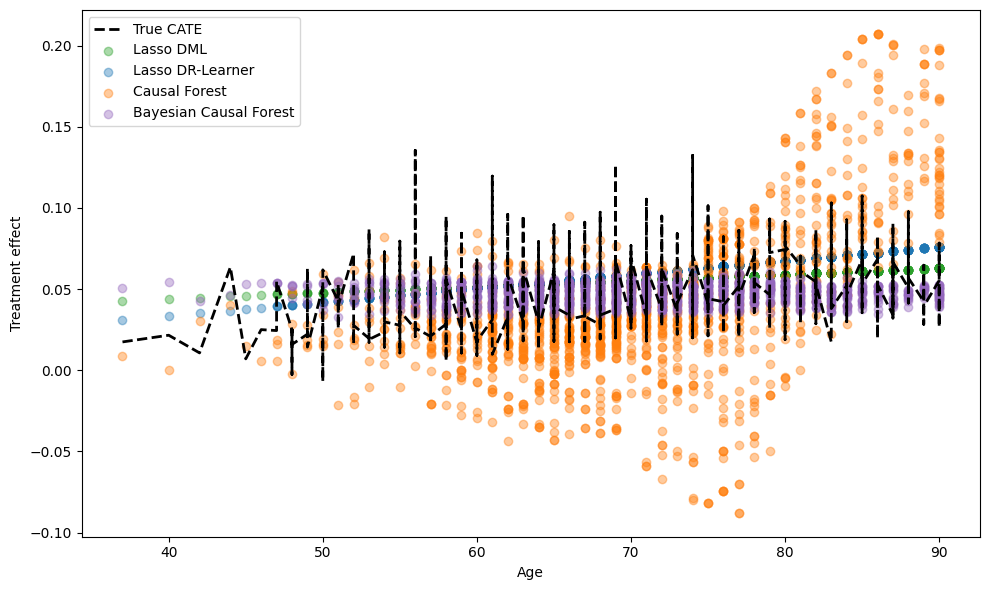

In [0]:
# plot the CATE estimation for each estimator against the continuous variable age, in comparison to the truth of CATE
var = "age"
subset = pdf[(pdf["Charlson"] == 0) & (pdf["cvd_pre"] == 0)]
order = np.argsort(subset[var])
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(subset[var].values[order], subset["true_cate"].values[order], label="True CATE", color="black", ls='--', linewidth=2)
# Define a color palette (distinct colors for each estimator)
palette = [
    "#2ca02c",  # green
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#9467bd",  # purple
]

name_map = {
    "BayesianCausalForest": "Bayesian Causal Forest",
    "CausalForest": "Causal Forest",
    "GbrDML": "GBR DML",
    "GbrDR": "GBR DR-Learner",
    "LassoDML": "Lasso DML",
    "LassoDR": "Lasso DR-Learner",
    "LinearDML": "Standard Linear DML",
    "LinearDR": "Standard Linear DR-Learner",
    "XLearner-GBR": "GBR X-Learner",
    "XLearner-Lasso": "Lasso X-Learner"
}

type_map = {
    "Bayesian Causal Forest": "Tree-based",
    "Causal Forest": "Tree-based",
    "Standard Linear DML": "Standard Linear",
    "Lasso DML": "Lasso",
    "GBR DML": "GBR",
    "Standard Linear DR-Learner": "Standard Linear",
    "Lasso DR-Learner": "Lasso",
    "GBR DR-Learner": "GBR",
    "Lasso X-Learner": "Lasso",
    "GBR X-Learner": "GBR"
}

# Only keep estimators that are "Standard Linear" or "Tree-based"
allowed_types = {"Lasso", "Tree-based"}

# Collect estimator names in plotting order for color assignment
plot_names = []
for name in cate_results:
    display_name = name_map.get(name, name)
    est_type = type_map.get(display_name, None)
    if est_type in allowed_types:
        plot_names.append(name)

for i, name in enumerate(plot_names):
    cate_hat = cate_results[name]
    display_name = name_map.get(name, name)
    color = palette[i % len(palette)]
    ax.scatter(subset[var].values[order], np.asarray(cate_hat)[subset.index][order], label=display_name, alpha=0.4, color=color)

ax.set_xlabel("Age")
ax.set_ylabel("Treatment effect")
#ax.set_title("CATE vs Age: Estimators vs Truth (Charlson=1, cvd_pre=0)")
ax.legend()
fig.tight_layout()

# save the plot to vector pdf
#fig.savefig(output_figure + "cate_vs_age.pdf", format="pdf", bbox_inches="tight")
plt.close(fig)
print(fig)  # replaced display()

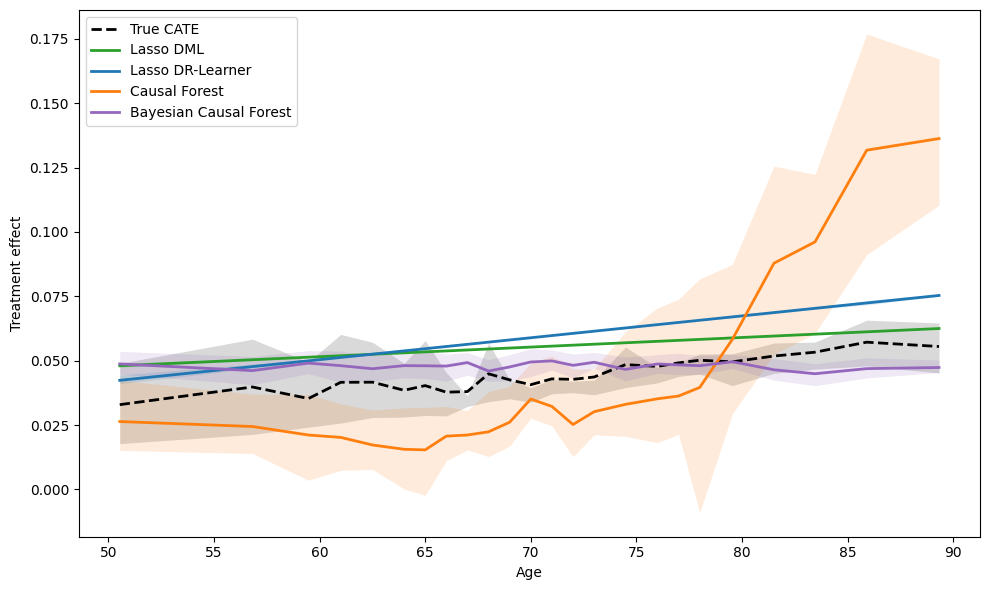

In [0]:
# update Feb 26, 2026: redo the figure above
# option 1: plot the CATE estimation for each estimator against age-binned averages to capture curve trends, in comparison to the truth of CATE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

var = "age"
subset = pdf[(pdf["Charlson"] == 0) & (pdf["cvd_pre"] == 0)].copy()
subset = subset.sort_values(var)

# bins: choose ~20–30 bins depending on n
n_bins = 25
subset["age_bin"] = pd.qcut(subset[var], q=n_bins, duplicates="drop")

# bin centers + true curve (binned)
bin_stats = subset.groupby("age_bin").agg(
    age_mid=(var, "mean"),
    true_mean=("true_cate", "mean"),
    true_lo=("true_cate", lambda x: np.quantile(x, 0.25)),
    true_hi=("true_cate", lambda x: np.quantile(x, 0.75)),
)

fig, ax = plt.subplots(figsize=(10, 6))

# True CATE as a binned mean curve (cleaner than jagged line)
ax.plot(bin_stats["age_mid"], bin_stats["true_mean"],
        label="True CATE", color="black", ls="--", linewidth=2)

# show within-bin variability of truth (helps interpret noise floor)
ax.fill_between(bin_stats["age_mid"], bin_stats["true_lo"], bin_stats["true_hi"],
                alpha=0.15, color="black", linewidth=0)

# plotting order chosen to match narrative and avoid palette-index mismatch
plot_order = ["LassoDML", "LassoDR", "CausalForest", "BayesianCausalForest"]
colors = {
    "LassoDML": "#2ca02c",
    "LassoDR": "#1f77b4",
    "CausalForest": "#ff7f0e",
    "BayesianCausalForest": "#9467bd",
}

for name in plot_order:
    if name not in cate_results:
        continue
    cate_hat = np.asarray(cate_results[name])[subset.index]  # align to subset rows

    tmp = subset[[var, "age_bin"]].copy()
    tmp["cate_hat"] = cate_hat

    est_bin = tmp.groupby("age_bin").agg(
        pred_mean=("cate_hat", "mean"),
        pred_lo=("cate_hat", lambda x: np.quantile(x, 0.25)),
        pred_hi=("cate_hat", lambda x: np.quantile(x, 0.75)),
    ).join(bin_stats[["age_mid"]])

    disp = name_map.get(name, name)

    ax.plot(est_bin["age_mid"], est_bin["pred_mean"],
            label=disp, color=colors[name], linewidth=2)

    # band shows variability; for CF this will widen at older ages if true
    ax.fill_between(est_bin["age_mid"], est_bin["pred_lo"], est_bin["pred_hi"],
                    color=colors[name], alpha=0.15, linewidth=0)

ax.set_xlabel("Age")
ax.set_ylabel("Treatment effect")
ax.legend(loc="upper left", frameon=True)
fig.tight_layout()
plt.close(fig)
print(fig)  # replaced display()

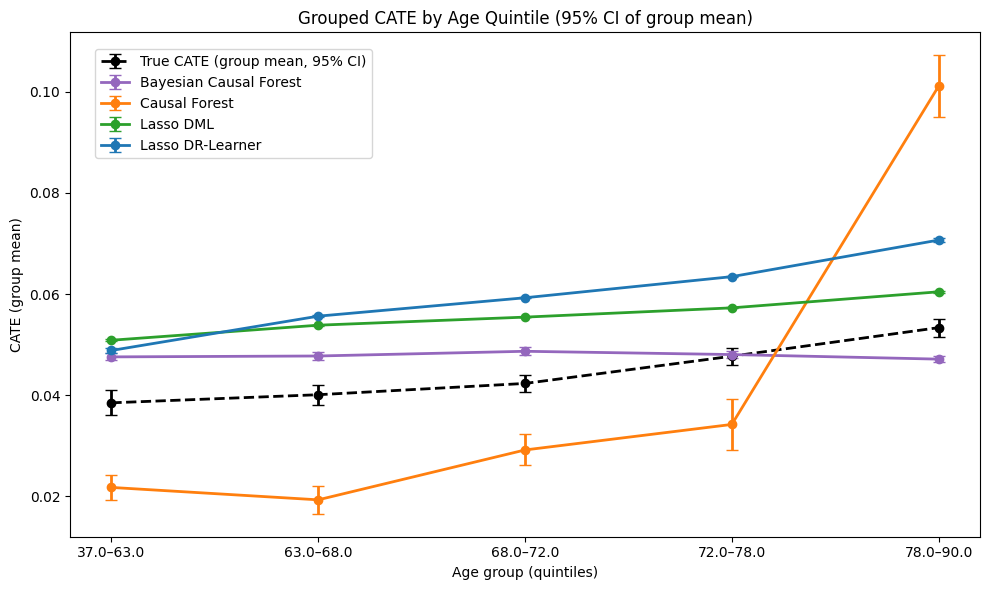

In [0]:
# option 2: CATE vs. age quitile group for selected estimators with a bar plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings: adjust as needed ---
var = "age"
subcond = (pdf["Charlson"] == 0) & (pdf["cvd_pre"] == 0)
n_groups = 5  # quintiles
plot_order = ["BayesianCausalForest", "CausalForest", "LassoDML", "LassoDR"]  # choose which methods to show
# readable display names
name_map = {
    "BayesianCausalForest": "Bayesian Causal Forest",
    "CausalForest": "Causal Forest",
    "GbrDML": "GBR DML",
    "GbrDR": "GBR DR-Learner",
    "LassoDML": "Lasso DML",
    "LassoDR": "Lasso DR-Learner",
    "LinearDML": "Standard Linear DML",
    "LinearDR": "Standard Linear DR-Learner",
    "XLearner-GBR": "GBR X-Learner",
    "XLearner-Lasso": "Lasso X-Learner"
}
# colors (expand if you add methods)
colors = {
    "BayesianCausalForest": "#9467bd",
    "CausalForest": "#ff7f0e",
    "LassoDML": "#2ca02c",
    "LassoDR": "#1f77b4",
}

# --- Prepare subset and groups ---
subset = pdf.loc[subcond].copy()
# Create quintile groups; drop duplicates if insufficient unique values
subset["age_group"] = pd.qcut(subset[var], q=n_groups, duplicates="drop")

# compute group-level x positions and labels
group_index = subset["age_group"].cat.categories
group_stats = subset.groupby("age_group").agg(
    age_mid=(var, "mean"),
    n_in_group=(var, "count"),
    true_mean=("true_cate", "mean"),
    true_sd=("true_cate", "std"),
)
group_stats = group_stats.reset_index()  # easier indexing
x = np.arange(len(group_stats))  # numeric x positions
x_labels = [
    f"{iv.left:.1f}–{iv.right:.1f}"
    for iv in group_index
]

# --- Helper to get aligned estimator predictions for the subset (safety) ---

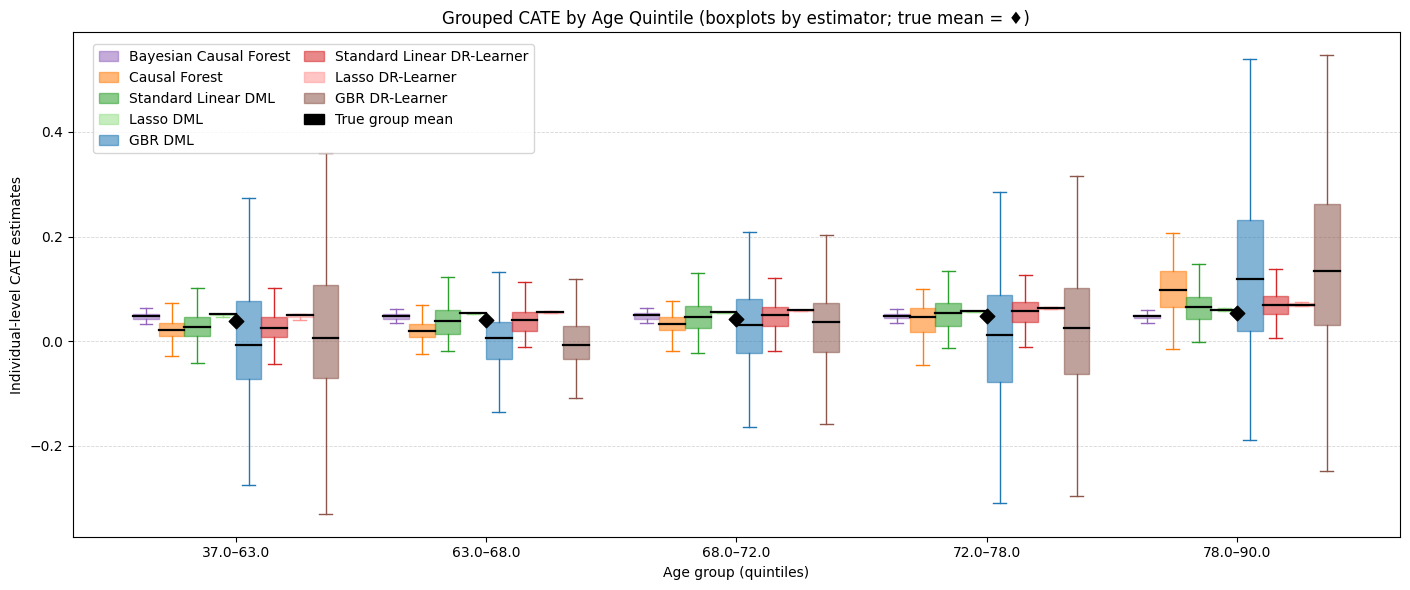

In [0]:
# option 3: CATE vs. age quitile group for estimators except X Learners with a box plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Settings ---
var = "age"
subcond = (pdf["Charlson"] == 0) & (pdf["cvd_pre"] == 0)
n_groups = 5  # quintiles

plot_order = [
    "BayesianCausalForest", "CausalForest",
    "LinearDML", "LassoDML", "GbrDML",
    "LinearDR", "LassoDR", "GbrDR",
]

name_map = {
    "BayesianCausalForest": "Bayesian Causal Forest",
    "CausalForest": "Causal Forest",
    "GbrDML": "GBR DML",
    "GbrDR": "GBR DR-Learner",
    "LassoDML": "Lasso DML",
    "LassoDR": "Lasso DR-Learner",
    "LinearDML": "Standard Linear DML",
    "LinearDR": "Standard Linear DR-Learner",
}

# Give EVERY estimator a color (so nothing falls back to white)
# (pick your own palette if you prefer)
colors = {
    "BayesianCausalForest": "#9467bd",
    "CausalForest": "#ff7f0e",
    "LinearDML": "#2ca02c",
    "LassoDML": "#98df8a",
    "GbrDML": "#1f77b4",
    "LinearDR": "#d62728",
    "LassoDR": "#ff9896",
    "GbrDR": "#8c564b",
}

# --- Prepare subset and quintile groups ---
subset = pdf.loc[subcond].copy()
subset["age_group"] = pd.qcut(subset[var], q=n_groups, duplicates="drop")
group_index = subset["age_group"].cat.categories
n_groups_actual = len(group_index)
x = np.arange(n_groups_actual)

def aligned_preds(name: str) -> np.ndarray:
    preds_full = pd.Series(cate_results[name], index=pdf.index)
    return preds_full.loc[subset.index].to_numpy()

# --- Collect group-wise arrays for each estimator ---
data_matrix = {}
for name in plot_order:
    if name not in cate_results:
        continue

    tmp = subset[[var, "age_group"]].copy()
    tmp["pred"] = aligned_preds(name)

    group_lists = []
    for g in group_index:
        vals = tmp.loc[tmp["age_group"] == g, "pred"].to_numpy()
        vals = vals[~np.isnan(vals)]
        group_lists.append(vals if vals.size else np.array([np.nan]))
    data_matrix[name] = group_lists

# --- True group means overlay ---
true_group_means = []
for g in group_index:
    vals = subset.loc[subset["age_group"] == g, "true_cate"].to_numpy()
    vals = vals[~np.isnan(vals)]
    true_group_means.append(np.nanmean(vals) if vals.size else np.nan)

# --- Plot ---
n_methods = len(data_matrix)
fig_w = max(10, 1.4 * n_groups_actual + 0.9 * n_methods)  # auto-widen with more estimators
fig, ax = plt.subplots(figsize=(fig_w, 6))

# spacing within each age group
total_width = 0.82
box_width = min(0.12, total_width / max(n_methods, 1))  # cap width so boxes don't get too fat
offsets = np.linspace(-total_width/2 + box_width/2, total_width/2 - box_width/2, n_methods) if n_methods > 1 else np.array([0.0])

# consistent line widths
lw = 1.0
median_lw = 1.6

# Draw one boxplot call per estimator (across all groups)
for i, (name, group_lists) in enumerate(data_matrix.items()):
    positions = x + offsets[i]

    bp = ax.boxplot(
        group_lists,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=False,
        boxprops=dict(linewidth=lw),
        whiskerprops=dict(linewidth=lw),
        capprops=dict(linewidth=lw),
        medianprops=dict(linewidth=median_lw),
    )

    c = colors.get(name, "#cccccc")
    # Apply color to all parts so it never looks "missing"
    for patch in bp["boxes"]:
        patch.set_facecolor(c)
        patch.set_edgecolor(c)
        patch.set_alpha(0.55)
    for line in bp["whiskers"] + bp["caps"]:
        line.set_color(c)
    for med in bp["medians"]:
        med.set_color("black")  # keeps medians readable across colors

# True mean as a single marker per group (center)
ax.scatter(x, true_group_means, marker="D", color="black", s=55, zorder=5, label="True group mean")

# --- Axes formatting ---
x_labels = [f"{iv.left:.1f}–{iv.right:.1f}" for iv in group_index]
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=0)
ax.set_xlabel("Age group (quintiles)")
ax.set_ylabel("Individual-level CATE estimates")
ax.set_title("Grouped CATE by Age Quintile (boxplots by estimator; true mean = ♦)")

# Improve readability: light grid + extra bottom margin
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.set_axisbelow(True)

# --- Legend (not crowded) ---
handles = []
for name in plot_order:
    if name in data_matrix:
        handles.append(mpatches.Patch(facecolor=colors.get(name, "#cccccc"), edgecolor=colors.get(name, "#cccccc"),
                                      alpha=0.55, label=name_map.get(name, name)))
handles.append(mpatches.Patch(facecolor="black", edgecolor="black", label="True group mean"))

# Use multi-column legend to avoid a tall block
ncol = 2 if len(handles) > 6 else 1
ax.legend(handles=handles, loc="upper left", frameon=True, ncol=ncol,
          columnspacing=1.0, handlelength=1.4, bbox_to_anchor=(0.01, 0.99))

fig.tight_layout()
plt.show()

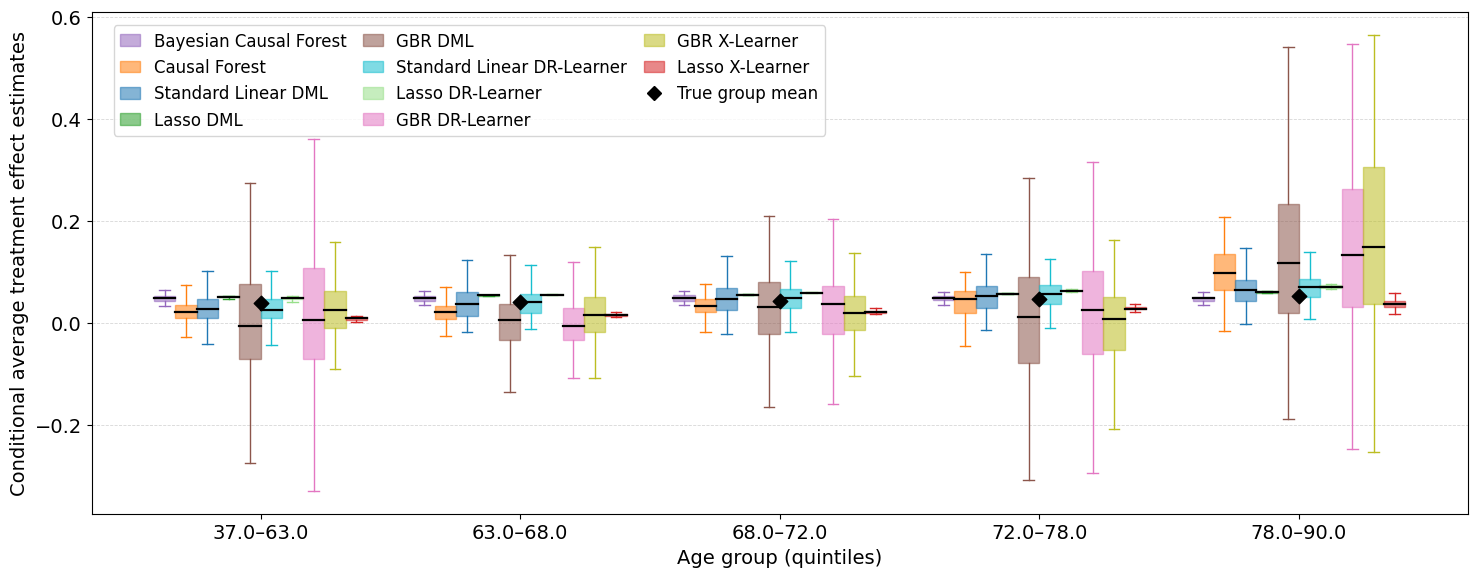

In [0]:
# option 4: CATE vs. age quitile group for all estimators with a box plot [final choice]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 14,           # base font size
    "axes.titlesize": 18,      # title
    "axes.labelsize": 16,      # axis labels
    "xtick.labelsize": 14,     # x tick labels
    "ytick.labelsize": 14,     # y tick labels
    "legend.fontsize": 12,     # legend text
})

# --- Settings ---
var = "age"
subcond = (pdf["Charlson"] == 0) & (pdf["cvd_pre"] == 0)
n_groups = 5  # quintiles

plot_order = [
    "BayesianCausalForest", "CausalForest",
    "LinearDML", "LassoDML", "GbrDML",
    "LinearDR", "LassoDR", "GbrDR",
    "XLearner-GBR", "XLearner-Lasso"
]

name_map = {
    "BayesianCausalForest": "Bayesian Causal Forest",
    "CausalForest": "Causal Forest",
    "GbrDML": "GBR DML",
    "GbrDR": "GBR DR-Learner",
    "LassoDML": "Lasso DML",
    "LassoDR": "Lasso DR-Learner",
    "LinearDML": "Standard Linear DML",
    "LinearDR": "Standard Linear DR-Learner",
    "XLearner-GBR": "GBR X-Learner",
    "XLearner-Lasso": "Lasso X-Learner"
}

# Give EVERY estimator a color
# (pick your own palette if you prefer)
colors = {
    # Forest-based
    "BayesianCausalForest": "#9467bd",   # purple
    "CausalForest": "#ff7f0e",           # orange

    # DML
    "LinearDML": "#1f77b4",              # blue
    "LassoDML": "#2ca02c",               # green
    "GbrDML": "#8c564b",                 # brown

    # DR
    "LinearDR": "#17becf",               # cyan
    "LassoDR": "#98df8a",                # light green
    "GbrDR": "#e377c2",                  # pink

    # X-Learners (new)
    "XLearner-GBR": "#bcbd22",           # olive
    "XLearner-Lasso": "#d62728",        # red
}

# --- Prepare subset and quintile groups ---
subset = pdf.loc[subcond].copy()
subset["age_group"] = pd.qcut(subset[var], q=n_groups, duplicates="drop")
group_index = subset["age_group"].cat.categories
n_groups_actual = len(group_index)
x = np.arange(n_groups_actual)

def aligned_preds(name: str) -> np.ndarray:
    preds_full = pd.Series(cate_results[name], index=pdf.index)
    return preds_full.loc[subset.index].to_numpy()

# --- Collect group-wise arrays for each estimator ---
data_matrix = {}
for name in plot_order:
    if name not in cate_results:
        continue

    tmp = subset[[var, "age_group"]].copy()
    tmp["pred"] = aligned_preds(name)

    group_lists = []
    for g in group_index:
        vals = tmp.loc[tmp["age_group"] == g, "pred"].to_numpy()
        vals = vals[~np.isnan(vals)]
        group_lists.append(vals if vals.size else np.array([np.nan]))
    data_matrix[name] = group_lists

# --- True group means overlay ---
true_group_means = []
for g in group_index:
    vals = subset.loc[subset["age_group"] == g, "true_cate"].to_numpy()
    vals = vals[~np.isnan(vals)]
    true_group_means.append(np.nanmean(vals) if vals.size else np.nan)

# --- Plot ---
n_methods = len(data_matrix)
fig_w = max(12, 1.2 * n_groups_actual + 0.9 * n_methods)  # auto-widen with more estimators
fig, ax = plt.subplots(figsize=(fig_w, 6))

# spacing within each age group
total_width = 0.82
box_width = min(0.12, total_width / max(n_methods, 1))  # cap width so boxes don't get too fat
offsets = np.linspace(-total_width/2 + box_width/2, total_width/2 - box_width/2, n_methods) if n_methods > 1 else np.array([0.0])

# consistent line widths
lw = 1.0
median_lw = 1.6

# Draw one boxplot call per estimator (across all groups)
for i, (name, group_lists) in enumerate(data_matrix.items()):
    positions = x + offsets[i]

    bp = ax.boxplot(
        group_lists,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=False,
        boxprops=dict(linewidth=lw),
        whiskerprops=dict(linewidth=lw),
        capprops=dict(linewidth=lw),
        medianprops=dict(linewidth=median_lw),
    )

    c = colors.get(name, "#cccccc")
    # Apply color to all parts 
    for patch in bp["boxes"]:
        patch.set_facecolor(c)
        patch.set_edgecolor(c)
        patch.set_alpha(0.55)
    for line in bp["whiskers"] + bp["caps"]:
        line.set_color(c)
    for med in bp["medians"]:
        med.set_color("black")  # keeps medians readable across colors

# True mean as a single marker per group (center)
ax.scatter(x, true_group_means, marker="D", color="black", s=55, zorder=5, label="True group mean")

# --- Axes formatting ---
x_labels = [f"{iv.left:.1f}–{iv.right:.1f}" for iv in group_index]
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=0)
ax.set_xlabel("Age group (quintiles)")
ax.set_ylabel("Conditional average treatment effect estimates")
#ax.set_title("Grouped CATE by Age Quintile (boxplots by estimator; true mean = ♦)")

# Improve readability: light grid + extra bottom margin
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.set_axisbelow(True)

# --- Legend (not crowded) ---
handles = []

# Estimator colored boxes
for name in plot_order:
    if name in data_matrix:
        handles.append(
            mpatches.Patch(
                facecolor=colors.get(name, "#cccccc"),
                edgecolor=colors.get(name, "#cccccc"),
                alpha=0.55,
                label=name_map.get(name, name)
            )
        )

# True group mean as diamond marker (matches scatter)
handles.append(
    Line2D(
        [0], [0],
        marker="D",
        color="black",
        linestyle="None",
        markersize=7,
        label="True group mean"
    )
)

# Use multi-column legend to avoid a tall block
ncol = 2 if len(handles) <= 10 else 3

ax.legend(
    handles=handles,
    loc="upper left",
    frameon=True,
    ncol=ncol,
    columnspacing=1.0,
    handlelength=1.2,
    bbox_to_anchor=(0.01, 0.99)
)

fig.savefig(
    output_figure + "cate_box_age.pdf", 
    format="pdf", # for paper
    bbox_inches="tight") 
fig.savefig(
    output_figure + "cate_box_age.png", #for slides 
    dpi=400,             
    bbox_inches="tight"
)
fig.tight_layout()
plt.show()